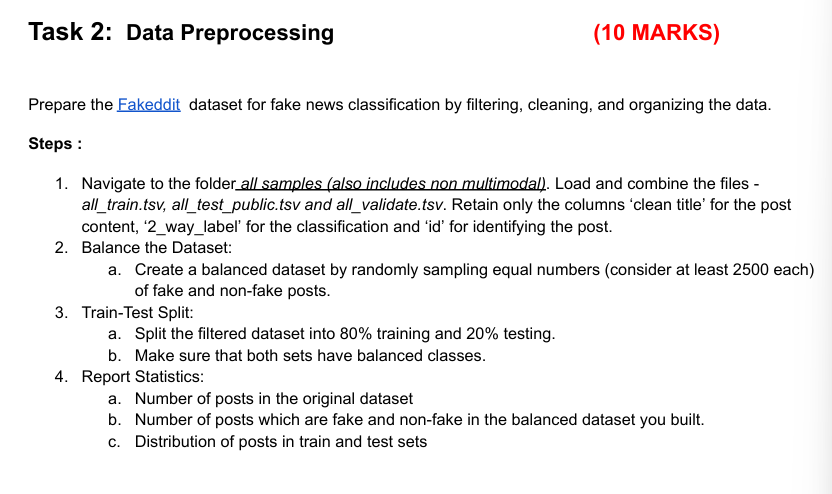

**Task 2:  Data Preprocessing**

In [4]:
!pip install pandas transformers torch

import torch
import pandas as pd
import numpy as np
from transformers import BertTokenizer, BertForSequenceClassification
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

In [5]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import math

In [6]:
import os

# base_path = "/content/drive/MyDrive/Fakeddit datasetv2.0/all_samples (also includes non multimodal)/"
base_path = "/kaggle/input/datasets/subhaorku/fakeddit-dataset/all_samples (also includes non multimodal)"
train_file = os.path.join(base_path, "all_train.tsv")
test_file = os.path.join(base_path, "all_test_public.tsv")
valid_file = os.path.join(base_path, "all_validate.tsv")

In [7]:
import pandas as pd

df_train = pd.read_csv(train_file, sep='\t')
df_test = pd.read_csv(test_file, sep='\t')
df_valid = pd.read_csv(valid_file, sep='\t')

# Combine all
df = pd.concat([df_train, df_test, df_valid], ignore_index=True)

print("Original dataset size:", len(df))

Original dataset size: 1063106


In [8]:
df = df[['id', 'clean_title', '2_way_label']]


df = df.dropna() # dropped missing values
df['clean_title'] = df['clean_title'].astype(str)
df['2_way_label'] = df['2_way_label'].astype(int)

print("Dataset after filtering:", len(df))

Dataset after filtering: 971806


In [9]:
class_counts = df['2_way_label'].value_counts()

print("\nOriginal class distribution:")
print(class_counts)


Original class distribution:
2_way_label
0    487085
1    484721
Name: count, dtype: int64


In [10]:
import numpy as np

# Separate classes
fake_df = df[df['2_way_label'] == 1]
real_df = df[df['2_way_label'] == 0]

print("\nFake samples:", len(fake_df))
print("Real samples:", len(real_df))


sample_size = min(len(fake_df), len(real_df), 20000)

# Random Sampling
fake_sampled = fake_df.sample(n=sample_size, random_state=42)
real_sampled = real_df.sample(n=sample_size, random_state=42)

# Combine both classes and shuffle
balanced_df = pd.concat([fake_sampled, real_sampled])
balanced_df = balanced_df.sample(frac=1, random_state=42).reset_index(drop=True) # frac = 1 will shuffe all rows otherwise model may learn wrong patterns
# after shuffle we would get proper mixing
print("\nBalanced dataset size:", len(balanced_df))


Fake samples: 484721
Real samples: 487085

Balanced dataset size: 40000


In [11]:
from sklearn.model_selection import train_test_split

train_df, test_df = train_test_split(
    balanced_df,
    test_size=0.2,
    stratify=balanced_df['2_way_label'],
    random_state=42
)
# stratify = .... , ensures Class distribution is preserved in both the sets
print("\nTrain size:", len(train_df))
print("Test size:", len(test_df))


Train size: 32000
Test size: 8000


In [12]:
print("\nTrain distribution:")
print(train_df['2_way_label'].value_counts())

print("\nTest distribution:")
print(test_df['2_way_label'].value_counts())


Train distribution:
2_way_label
0    16000
1    16000
Name: count, dtype: int64

Test distribution:
2_way_label
1    4000
0    4000
Name: count, dtype: int64


In [13]:
train_df.to_csv("/content/train_processed.csv", index=False)
test_df.to_csv("/content/test_processed.csv", index=False)

**Task 1: Implement BERT class from scratch**

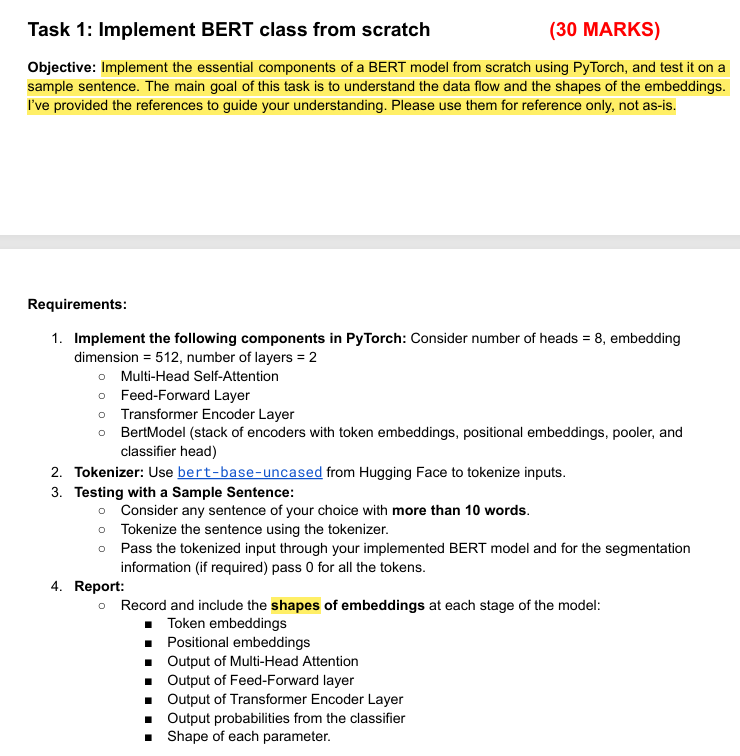

In [14]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import math

**MULTI-HEAD SELF ATTENTION**

In [15]:
class MultiHeadSelfAttention(nn.Module):
    def __init__(self, embed_dim=512, num_heads=8):
        super().__init__()

        assert embed_dim % num_heads == 0

        self.embed_dim = embed_dim
        self.num_heads = num_heads
        self.head_dim = embed_dim // num_heads  # 512 / 8 = 64

        # Linear projections
        self.W_q = nn.Linear(embed_dim, embed_dim)
        self.W_k = nn.Linear(embed_dim, embed_dim)
        self.W_v = nn.Linear(embed_dim, embed_dim)

        self.W_o = nn.Linear(embed_dim, embed_dim)

    def forward(self, x):
        B, L, D = x.shape

        # Linear projections
        Q = self.W_q(x)  # (B, L, 512)
        K = self.W_k(x)
        V = self.W_v(x)

        # Spliting into heads
        Q = Q.view(B, L, self.num_heads, self.head_dim).transpose(1, 2)
        K = K.view(B, L, self.num_heads, self.head_dim).transpose(1, 2)
        V = V.view(B, L, self.num_heads, self.head_dim).transpose(1, 2)

        # Shapes: (B, heads, L, head_dim) = (B, 8, L, 64)

        # Attention scores
        scores = torch.matmul(Q, K.transpose(-2, -1)) / math.sqrt(self.head_dim)
        # (B, 8, L, L)

        attn = torch.softmax(scores, dim=-1)

        # Weighted sum of value vectors
        out = torch.matmul(attn, V)  # (B, 8, L, 64)

        # Concatenate the heads
        out = out.transpose(1, 2).contiguous().view(B, L, D)  # (B, L, 512)

        output = self.W_o(out)  # (B, L, 512)

        return output

**FEED FORWARD NETWORK**

In [16]:
class FeedForward(nn.Module):
    def __init__(self, embed_dim=512, hidden_dim=2048):
        super().__init__()

        self.fc1 = nn.Linear(embed_dim, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, embed_dim)

    def forward(self, x):
        # (B, L, 512) → (B, L, 2048) → (B, L, 512)
        return self.fc2(F.relu(self.fc1(x)))
        # fc1: 512 → 2048
        # fc2: 2048 → 512

**TRANSFORMER ENCODER LAYER**

In [17]:
class EncoderLayer(nn.Module):
    def __init__(self, embed_dim=512, num_heads=8):
        super().__init__()

        self.mha = MultiHeadSelfAttention(embed_dim, num_heads)
        self.ffn = FeedForward(embed_dim)

        self.norm1 = nn.LayerNorm(embed_dim)
        self.norm2 = nn.LayerNorm(embed_dim)

    def forward(self, x):
        # Multi-head attention
        mha_out = self.mha(x)
        x = self.norm1(x + mha_out)

        # Feed forward
        ffn_out = self.ffn(x)
        x = self.norm2(x + ffn_out)

        return x, mha_out, ffn_out

**BERT MODEL**

In [18]:
class BertModel(nn.Module):
    def __init__(self, vocab_size=30522, max_len=32, embed_dim=512, num_heads=8, num_layers=2):
        super().__init__()

        self.embed_dim = embed_dim

        # Embeddings (1,20,512), x = token_embed + PE
        self.token_embeddings = nn.Embedding(vocab_size, embed_dim)
        self.position_embeddings = nn.Embedding(max_len, embed_dim)

        # Encoder stack of 2 layers, (1,20,512)
        self.layers = nn.ModuleList([
            EncoderLayer(embed_dim, num_heads) for _ in range(num_layers)
        ])

        # Pooler (CLS) so that first token gives summary of sentence!, (B,512)
        self.pooler = nn.Linear(embed_dim, embed_dim)

        # Classifier (fake / real)
        self.classifier = nn.Linear(embed_dim, 2)

    def forward(self, input_ids):
        B, L = input_ids.shape

        # Positions
        positions = torch.arange(0, L).unsqueeze(0).expand(B, L)

        # Embeddings
        token_embed = self.token_embeddings(input_ids)
        pos_embed = self.position_embeddings(positions)

        x = token_embed + pos_embed

        print("\n--- Embedding Stage ---")
        print("Token Embeddings:", token_embed.shape)
        print("Positional Embeddings:", pos_embed.shape)

        # Pass through encoder layers
        for i, layer in enumerate(self.layers):
            x, mha_out, ffn_out = layer(x)

            print(f"\n--- Encoder Layer {i+1} ---")
            print("MHA Output:", mha_out.shape)
            print("FFN Output:", ffn_out.shape)
            print("Encoder Output:", x.shape)

        # CLS token
        cls_token = x[:, 0]  # (B, 512)

        pooled = torch.tanh(self.pooler(cls_token))

        logits = self.classifier(pooled)
        probs = torch.softmax(logits, dim=-1)

        print("\n  Final Output ")
        print("Classifier Output:", probs.shape)

        return probs

**TOKENIZER + SAMPLE TEST**

In [19]:
from transformers import BertTokenizer

tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")

sentence = "The transformer model processes entire sequences in parallel and captures relationships between words effectively"

encoded = tokenizer(
    sentence,
    padding='max_length',
    truncation=True,
    max_length=20,
    return_tensors='pt'
)

input_ids = encoded['input_ids']

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

In [20]:
# 1. Tokens (words/subwords)
tokens = tokenizer.tokenize(sentence)
print("Tokens:\n", tokens)

# 2. Tokens with special tokens
tokens_with_special = tokenizer.convert_ids_to_tokens(encoded['input_ids'][0])
print("\nTokens with [CLS] and [SEP]:\n", tokens_with_special)

# 3. Token IDs
print("\nToken IDs:\n", encoded['input_ids'])

# 4. Attention mask
print("\nAttention Mask:\n", encoded['attention_mask']) # 1 -> for real token  and 0 -> for padding token

Tokens:
 ['the', 'transform', '##er', 'model', 'processes', 'entire', 'sequences', 'in', 'parallel', 'and', 'captures', 'relationships', 'between', 'words', 'effectively']

Tokens with [CLS] and [SEP]:
 ['[CLS]', 'the', 'transform', '##er', 'model', 'processes', 'entire', 'sequences', 'in', 'parallel', 'and', 'captures', 'relationships', 'between', 'words', 'effectively', '[SEP]', '[PAD]', '[PAD]', '[PAD]']

Token IDs:
 tensor([[  101,  1996, 10938,  2121,  2944,  6194,  2972, 10071,  1999,  5903,
          1998, 19566,  6550,  2090,  2616,  6464,   102,     0,     0,     0]])

Attention Mask:
 tensor([[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0]])


**RUN MODEL**

In [21]:
model = BertModel()

output = model(input_ids)

print("\nFinal Probabilities:", output)


--- Embedding Stage ---
Token Embeddings: torch.Size([1, 20, 512])
Positional Embeddings: torch.Size([1, 20, 512])

--- Encoder Layer 1 ---
MHA Output: torch.Size([1, 20, 512])
FFN Output: torch.Size([1, 20, 512])
Encoder Output: torch.Size([1, 20, 512])

--- Encoder Layer 2 ---
MHA Output: torch.Size([1, 20, 512])
FFN Output: torch.Size([1, 20, 512])
Encoder Output: torch.Size([1, 20, 512])

  Final Output 
Classifier Output: torch.Size([1, 2])

Final Probabilities: tensor([[0.5339, 0.4661]], grad_fn=<SoftmaxBackward0>)


**PARAMETER SHAPES (REQUIRED)**

In [22]:
print("\n--- Parameter Shapes ---\n")
for name, param in model.named_parameters():
    print(name, param.shape)


--- Parameter Shapes ---

token_embeddings.weight torch.Size([30522, 512])
position_embeddings.weight torch.Size([32, 512])
layers.0.mha.W_q.weight torch.Size([512, 512])
layers.0.mha.W_q.bias torch.Size([512])
layers.0.mha.W_k.weight torch.Size([512, 512])
layers.0.mha.W_k.bias torch.Size([512])
layers.0.mha.W_v.weight torch.Size([512, 512])
layers.0.mha.W_v.bias torch.Size([512])
layers.0.mha.W_o.weight torch.Size([512, 512])
layers.0.mha.W_o.bias torch.Size([512])
layers.0.ffn.fc1.weight torch.Size([2048, 512])
layers.0.ffn.fc1.bias torch.Size([2048])
layers.0.ffn.fc2.weight torch.Size([512, 2048])
layers.0.ffn.fc2.bias torch.Size([512])
layers.0.norm1.weight torch.Size([512])
layers.0.norm1.bias torch.Size([512])
layers.0.norm2.weight torch.Size([512])
layers.0.norm2.bias torch.Size([512])
layers.1.mha.W_q.weight torch.Size([512, 512])
layers.1.mha.W_q.bias torch.Size([512])
layers.1.mha.W_k.weight torch.Size([512, 512])
layers.1.mha.W_k.bias torch.Size([512])
layers.1.mha.W_v.wei

**Task 3: Fine tune the model and Report Metrics**

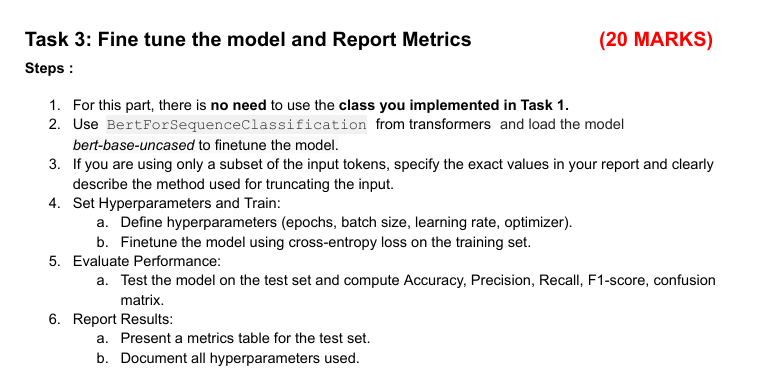

**WITH TRAIN + VALIDATION + TEST SPLIT**

**Load Preprocessed Dataset**

In [23]:
train_df = pd.read_csv("/content/train_processed.csv")
test_df = pd.read_csv("/content/test_processed.csv")

print(train_df.head())

        id                                        clean_title  2_way_label
0  c7unjpm                                 unless youd prefer            0
1   42tkpm  dallas dad not guilty for taking tween daughte...            1
2   7m0shx  mutant catfish one year after the chernobyl fa...            0
3  cg8iji0                                  other discussions            0
4   7tumpu  elon musk sells m worth of flamethrowers in a day            1


In [24]:
from sklearn.model_selection import train_test_split

train_df, val_df = train_test_split(
    train_df,
    test_size=0.15,
    stratify=train_df['2_way_label'],
    random_state=42
)

print("Train size:", len(train_df))
print("Validation size:", len(val_df))

Train size: 27200
Validation size: 4800


**Dataset Class**

In [25]:
class FakeNewsDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = str(self.texts[idx])
        label = int(self.labels[idx])

        encoding = self.tokenizer(
            text,
            padding='max_length',
            truncation=True,
            max_length=self.max_len,
            return_tensors='pt'
        )

        return {
            'input_ids': encoding['input_ids'].squeeze(0),
            'attention_mask': encoding['attention_mask'].squeeze(0),
            'labels': torch.tensor(label, dtype=torch.long)
        }

**Tokenizer**

In [26]:
tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")

MAX_LEN = 64   #  IMPORTANT: Mentioned in report

**Create Datasets**

In [27]:
train_dataset = FakeNewsDataset(
    train_df['clean_title'].values,
    train_df['2_way_label'].values,
    tokenizer,
    MAX_LEN
)

val_dataset = FakeNewsDataset(
    val_df['clean_title'].values,
    val_df['2_way_label'].values,
    tokenizer,
    MAX_LEN
)

test_dataset = FakeNewsDataset(
    test_df['clean_title'].values,
    test_df['2_way_label'].values,
    tokenizer,
    MAX_LEN
)

**DataLoader**

In [28]:
BATCH_SIZE = 16

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE)

**Load Pretrained BERT Model**

In [29]:
from transformers import BertForSequenceClassification
# we import a ready-made BERT model designed for classification tasks
model = BertForSequenceClassification.from_pretrained(
    "bert-base-uncased",
    num_labels=2
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12,

**Freezing first 6 layers**

In [30]:
# Freeze embeddings
for param in model.bert.embeddings.parameters():
    param.requires_grad = False

# Freeze first 6 encoder layers
for layer in model.bert.encoder.layer[:6]:
    for param in layer.parameters():
        param.requires_grad = False

In [31]:
from torch.optim import AdamW
from transformers.optimization import get_linear_schedule_with_warmup
import torch

**Hyperparameters**

In [32]:
EPOCHS = 5
LEARNING_RATE = 1e-5

# optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE)

# ================================
# OPTIMIZER WITH WEIGHT DECAY
# ================================
optimizer = AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=1e-5,
    weight_decay=0.01
)

In [33]:
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total = sum(p.numel() for p in model.parameters())

print(f"Trainable params: {trainable}")
print(f"Total params: {total}")

Trainable params: 43119362
Total params: 109483778


**Training Loop**

In [34]:
# ================================
# SCHEDULER (FOR generalization)
# ================================
total_steps = len(train_loader) * EPOCHS

scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=int(0.1 * total_steps),
    num_training_steps=total_steps
)

# ================================
# EARLY STOPPING SETUP
# ================================
best_val_loss = float('inf')
patience = 2
counter = 0

# ================================
# TRAINING LOOP
# ================================
for epoch in range(EPOCHS):

    # ===== TRAIN =====
    model.train()
    total_train_loss = 0

    for batch in train_loader:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        optimizer.zero_grad()

        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            labels=labels
        )

        loss = outputs.loss
        total_train_loss += loss.item()

        loss.backward()

        #  Gradient clipping for stable learning, as I always do
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)

        optimizer.step()
        scheduler.step()  

    avg_train_loss = total_train_loss / len(train_loader)

    # ===== VALIDATION =====
    model.eval()
    total_val_loss = 0

    with torch.no_grad():
        for batch in val_loader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)

            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask,
                labels=labels
            )

            loss = outputs.loss
            total_val_loss += loss.item()

    avg_val_loss = total_val_loss / len(val_loader)

    print(f"\nEpoch {epoch+1}/{EPOCHS}")
    print(f"Train Loss: {avg_train_loss:.4f}")
    print(f"Validation Loss: {avg_val_loss:.4f}")

    # ===== SAVE BEST MODEL =====
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        torch.save(model.state_dict(), "best_model.pth")
        print(" Best model saved!")

        counter = 0  # reset patience counter
    else:
        counter += 1
        print(f" No improvement. Patience: {counter}/{patience}")

        # ===== EARLY STOPPING =====
        if counter >= patience:
            print(" Early stopping triggered!")
            break


Epoch 1/5
Train Loss: 0.4974
Validation Loss: 0.4112
 Best model saved!

Epoch 2/5
Train Loss: 0.3775
Validation Loss: 0.3808
 Best model saved!

Epoch 3/5
Train Loss: 0.3282
Validation Loss: 0.3923
 No improvement. Patience: 1/2

Epoch 4/5
Train Loss: 0.2949
Validation Loss: 0.3949
 No improvement. Patience: 2/2
 Early stopping triggered!


**Evaluation**

In [35]:
model.load_state_dict(torch.load("best_model.pth"))
model.to(device)
model.eval()

print(" Best model loaded successfully!")

 Best model loaded successfully!


In [36]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

all_preds = []
all_labels = []

with torch.no_grad():
    for batch in test_loader:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask
        )

        logits = outputs.logits
        preds = torch.argmax(logits, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

**Metrics**

In [37]:
accuracy = accuracy_score(all_labels, all_preds)
precision = precision_score(all_labels, all_preds)
recall = recall_score(all_labels, all_preds)
f1 = f1_score(all_labels, all_preds)

cm = confusion_matrix(all_labels, all_preds)

print("\n--- Evaluation Metrics ---")
print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)

print("\nConfusion Matrix:")
print(cm)


--- Evaluation Metrics ---
Accuracy: 0.834625
Precision: 0.839634610504948
Recall: 0.82725
F1 Score: 0.8333962976955044

Confusion Matrix:
[[3368  632]
 [ 691 3309]]


**Metrics Table**

In [38]:
results = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1 Score"],
    "Value": [accuracy, precision, recall, f1]
})

print("\nMetrics Table:\n")
print(results)


Metrics Table:

      Metric     Value
0   Accuracy  0.834625
1  Precision  0.839635
2     Recall  0.827250
3   F1 Score  0.833396


**Task 4: Use Integrated Gradients for token attribution**

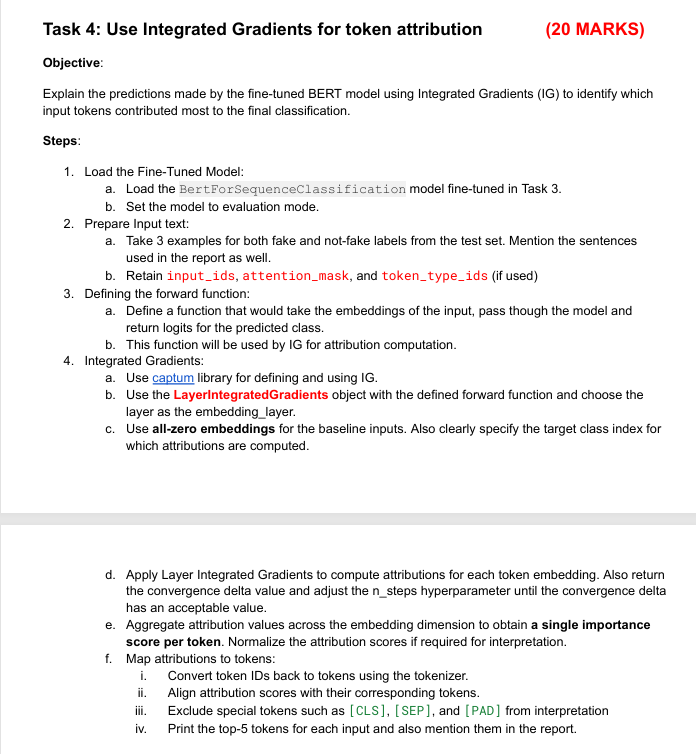

In [39]:
!pip install captum

import torch
import numpy as np
import pandas as pd

from transformers import BertTokenizer, BertForSequenceClassification
from captum.attr import LayerIntegratedGradients

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 22.2 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 69.2 MB/s eta 0:00:00:00:0100:01
  Attempting uninstall: numpy
    Found existing installation: numpy 2.0.2
    Uninstalling numpy-2.0.2:
      Successfully uninstalled numpy-2.0.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
bigframes 2.35.0 requires google-cloud-bigquery-storage<3.0.0,>=2.30.0, which is not installed.
kaggle-environments 1.27.3 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
cesium 0.12.4 requires numpy<3.0,>=2.0, but you have numpy 1.26.4 which is incompatible.
google-colab 1.0.0 requires jupyter-server==2.14.0, but you have jupyter-server 2.12.5 which is incompatible.
google-colab 1.0.0 requires p

**With n_step tuning**

In [40]:
import torch
import pandas as pd
from transformers import BertTokenizer, BertForSequenceClassification
from captum.attr import LayerIntegratedGradients

# ================================
# 1. LOAD MODEL
# ================================
tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")

model = BertForSequenceClassification.from_pretrained(
    "bert-base-uncased",
    num_labels=2
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model.load_state_dict(torch.load("best_model.pth", map_location=device)) # Load model weights
model.to(device)
model.eval()

print(" Model loaded and set to evaluation mode")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


 Model loaded and set to evaluation mode


In [41]:
state_dict = torch.load("best_model.pth", map_location="cpu")

print([k for k in state_dict.keys() if "classifier" in k])

['classifier.weight', 'classifier.bias']


In [42]:
print(model.classifier.weight[:2])

tensor([[ 0.0042, -0.0225, -0.0077,  ..., -0.0134,  0.0031, -0.0349],
        [-0.0064,  0.0248,  0.0023,  ...,  0.0048, -0.0229, -0.0069]],
       device='cuda:0', grad_fn=<SliceBackward0>)


In [43]:
model = BertForSequenceClassification.from_pretrained("bert-base-uncased", num_labels=2)

model.load_state_dict(torch.load("best_model.pth"))

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


<All keys matched successfully>

In [44]:
print(model.classifier.weight[:2])

tensor([[ 0.0042, -0.0225, -0.0077,  ..., -0.0134,  0.0031, -0.0349],
        [-0.0064,  0.0248,  0.0023,  ...,  0.0048, -0.0229, -0.0069]],
       grad_fn=<SliceBackward0>)


In [45]:
model.save_pretrained("my_model")
tokenizer.save_pretrained("my_model")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

('my_model/tokenizer_config.json', 'my_model/tokenizer.json')

In [46]:
model = BertForSequenceClassification.from_pretrained("my_model")
tokenizer = BertTokenizer.from_pretrained("my_model")

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

In [47]:
print(model)

BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12,

In [48]:
for name, param in model.named_parameters():
    print(name, param.shape)

bert.embeddings.word_embeddings.weight torch.Size([30522, 768])
bert.embeddings.position_embeddings.weight torch.Size([512, 768])
bert.embeddings.token_type_embeddings.weight torch.Size([2, 768])
bert.embeddings.LayerNorm.weight torch.Size([768])
bert.embeddings.LayerNorm.bias torch.Size([768])
bert.encoder.layer.0.attention.self.query.weight torch.Size([768, 768])
bert.encoder.layer.0.attention.self.query.bias torch.Size([768])
bert.encoder.layer.0.attention.self.key.weight torch.Size([768, 768])
bert.encoder.layer.0.attention.self.key.bias torch.Size([768])
bert.encoder.layer.0.attention.self.value.weight torch.Size([768, 768])
bert.encoder.layer.0.attention.self.value.bias torch.Size([768])
bert.encoder.layer.0.attention.output.dense.weight torch.Size([768, 768])
bert.encoder.layer.0.attention.output.dense.bias torch.Size([768])
bert.encoder.layer.0.attention.output.LayerNorm.weight torch.Size([768])
bert.encoder.layer.0.attention.output.LayerNorm.bias torch.Size([768])
bert.encoder

In [49]:
# ================================
# 2. PREPARE INPUT TEXT
# ================================
test_df = pd.read_csv("/content/test_processed.csv")

fake_samples = test_df[test_df['2_way_label'] == 1].sample(3, random_state=42)
real_samples = test_df[test_df['2_way_label'] == 0].sample(3, random_state=42)

samples = pd.concat([fake_samples, real_samples]).reset_index(drop=True)

print("\nSelected Sentences:\n")
for i, row in samples.iterrows():
    print(f"{i+1}. Label: {row['2_way_label']}")
    print(row['clean_title'], "\n")


Selected Sentences:

1. Label: 1
look at the black wonder what it was 

2. Label: 1
this still has the pressure inside from airplane altitude 

3. Label: 1
friezas graduation album 

4. Label: 0
eww what the hell 

5. Label: 0
foreboding panic total control of world fisting 

6. Label: 0
spider laying eggs on human face 



In [50]:
# ================================
# TOKENIZATION
# ================================
MAX_LEN = 64

def tokenize_text(text):
    encoding = tokenizer(
        text,
        padding='max_length',
        truncation=True,
        max_length=MAX_LEN,
        return_tensors='pt'
    )

    token_type_ids = encoding.get('token_type_ids')
    if token_type_ids is None:
        token_type_ids = torch.zeros_like(encoding['input_ids'])

    return {
        'input_ids': encoding['input_ids'].to(device),
        'attention_mask': encoding['attention_mask'].to(device),
        'token_type_ids': token_type_ids.to(device)
    }

In [51]:
# ================================
# 3. FORWARD FUNCTION
# Thhis Custom Forward Function will take the embeddings of i/p, pass through the model and return the logits
# we do this since IG needs gradients wrt embeddings
# ================================
def forward_func(inputs_embeds, attention_mask, token_type_ids):
    outputs = model(
        inputs_embeds=inputs_embeds,
        attention_mask=attention_mask,
        token_type_ids=token_type_ids
    )
    return outputs.logits

In [52]:
# ================================
# 4. INTEGRATED GRADIENTS SETUP
# This creates an object which can answer which all tokens contributed most to the prediction?
# IG cant compute gradients on discrete integers so we use embeddings which are continuous vectors
# ================================
lig = LayerIntegratedGradients(
    forward_func,
    model.bert.embeddings # apply attribution at the Bert embedding layer
)

In [53]:
# ================================
# 4d. FUNCTION TO AUTO-TUNE n_steps
# ================================
def compute_attributions(text):

    inputs = tokenize_text(text) # Tokenize the i/p text

    input_ids = inputs['input_ids']
    attention_mask = inputs['attention_mask']
    token_type_ids = inputs['token_type_ids']

    # Get embeddings
    embeddings = model.bert.embeddings(input_ids) # Convert input_ids to embeddings

    # Baseline
    baseline = torch.zeros_like(embeddings).to(device) # this represnts no info i/p

    # Get prediction
    outputs = model(
        inputs_embeds=embeddings, # we use embeddings and no i/p ids here since we have to do IG
        attention_mask=attention_mask,
        token_type_ids=token_type_ids
    )

    pred_class = torch.argmax(outputs.logits, dim=1).item()

    # ============================
    # AUTO-TUNING the hyper-parameter : n_steps
    # ============================
    best_attributions = None
    best_delta = None
    best_steps = None

    for steps in [50, 100, 200, 300]:
        attributions, delta = lig.attribute(
            inputs=embeddings,
            baselines=baseline,
            additional_forward_args=(attention_mask, token_type_ids),
            target=pred_class,
            n_steps=steps,
            return_convergence_delta=True
        ) # get the importance score( = attributions) and approximation error ( = delta)

        delta_val = abs(delta.item()) # this is my approximation error to measure how accurate IG approximation is

        print(f"  n_steps={steps} → delta={delta_val:.6f}")

        #  We Stop early if good convergence
        if delta_val < 0.01:
            best_attributions = attributions
            best_delta = delta.item()
            best_steps = steps
            break

        # Otherwise, keep the best obtained so far i.e lowest delta
        if best_delta is None or delta_val < abs(best_delta):
            best_attributions = attributions
            best_delta = delta.item()
            best_steps = steps

    print(f"   Selected n_steps={best_steps} with delta={best_delta:.6f}")

    # ============================
    # AGGREGATE THE ATTRIBUTIONS (To GET ONE IMPORTANCE SCORE PER TOKEN)
    # ============================
    attributions = best_attributions.sum(dim=-1).squeeze(0)

    # Normalize to prevent scalling issues
    attributions = attributions / (torch.norm(attributions) + 1e-8)

    tokens = tokenizer.convert_ids_to_tokens(input_ids[0])

    return tokens, attributions.detach().cpu().numpy(), best_delta

In [54]:
def compute_attributions(text):

    inputs = tokenize_text(text) # Tokenize the i/p text

    input_ids = inputs['input_ids'].to("cpu")
    attention_mask = inputs['attention_mask'].to("cpu")
    token_type_ids = inputs['token_type_ids'].to("cpu")

    # Move model to CPU
    model_cpu = model.to("cpu")
    
    # Get embeddings
    embeddings = model_cpu.bert.embeddings(input_ids) # Convert input_ids to embeddings

    # Baseline
    baseline = torch.zeros_like(embeddings) # this represnts no info i/p

    def forward_func_cpu(inputs_embeds, attention_mask, token_type_ids):
        outputs = model_cpu(
            inputs_embeds=inputs_embeds, 
            attention_mask=attention_mask,
            token_type_ids=token_type_ids
        )
        return outputs.logits

    lig_cpu = LayerIntegratedGradients(
        forward_func_cpu,
        model_cpu.bert.embeddings
    )

    # Get prediction 
    with torch.no_grad():
        outputs = model_cpu(
            inputs_embeds=embeddings,# we use embeddings and no i/p ids here since we have to do IG
            attention_mask=attention_mask,
            token_type_ids=token_type_ids
        )

    pred_class = torch.argmax(outputs.logits, dim=1).item()

    # ============================
    # AUTO-TUNING the hyper-parameter : n_steps
    # ============================

    best_attributions = None
    best_delta = None
    best_steps = None

    for steps in [50, 100, 150, 200, 250, 300]:
        attributions, delta = lig_cpu.attribute(
            inputs=embeddings,
            baselines=baseline,
            additional_forward_args=(attention_mask, token_type_ids),
            target=pred_class,
            n_steps=steps,
            return_convergence_delta=True
        ) # get the importance score( = attributions) and approximation error ( = delta)

        delta_val = abs(delta.item()) # this is my approximation error to measure how accurate IG approximation is
        print(f"  n_steps={steps} → delta={delta_val:.6f}")
       
        #  We Stop early if good convergence
        if delta_val < 0.01:
            best_attributions = attributions
            best_delta = delta.item()
            best_steps = steps
            break           
        
        # Otherwise, keep the best obtained so far, i.e., lowest delta
        if best_delta is None or delta_val < abs(best_delta):
            best_attributions = attributions
            best_delta = delta.item()
            best_steps = steps


    print(f"   Selected n_steps={best_steps} with delta={best_delta:.6f}")
    # AGGREGATE THE ATTRIBUTIONS (To GET ONE IMPORTANCE SCORE PER TOKEN)
    attributions = best_attributions.sum(dim=-1).squeeze(0)

    # Normalize to prevent scalling issues
    attributions = attributions / (torch.norm(attributions) + 1e-8)

    tokens = tokenizer.convert_ids_to_tokens(input_ids[0])

    # Moving model back to GPU
    model.to(device)

    return tokens, attributions.detach().cpu().numpy(), best_delta

In [55]:
# ================================
# 5. RUN ON SAMPLES
# ================================

# Loop through the samples
for i, row in samples.iterrows():
    text = row['clean_title'] # take the actual sentence to process it.......!

    print("\n" + "="*60)
    print(f"Sentence {i+1}:")
    print(text)

    tokens, scores, delta = compute_attributions(text)

    print(f"\nFinal Convergence Delta: {delta:.6f}")

    # I removed the special tokens as mentioned in the assignment task!
    filtered = [
        (tok, score)
        for tok, score in zip(tokens, scores)
        if tok not in ["[CLS]", "[SEP]", "[PAD]"]
    ]

    # Sort  the tokens by their importance score
    filtered = sorted(filtered, key=lambda x: abs(x[1]), reverse=True)

    print("\nTop 5 Important Tokens:")
    for tok, score in filtered[:5]:
        print(f"{tok}: {score:.4f}")


Sentence 1:
look at the black wonder what it was
  n_steps=50 → delta=3.148101
  n_steps=100 → delta=0.004263
   Selected n_steps=100 with delta=-0.004263

Final Convergence Delta: -0.004263

Top 5 Important Tokens:
what: 0.2803
wonder: 0.1648
was: -0.1043
it: -0.0859
black: -0.0617

Sentence 2:
this still has the pressure inside from airplane altitude
  n_steps=50 → delta=1.145270
  n_steps=100 → delta=0.226433
  n_steps=150 → delta=0.077284
  n_steps=200 → delta=0.083617
  n_steps=250 → delta=0.028147
  n_steps=300 → delta=0.083136
   Selected n_steps=250 with delta=-0.028147

Final Convergence Delta: -0.028147

Top 5 Important Tokens:
this: 0.5889
altitude: 0.3060
has: 0.1907
airplane: 0.1145
inside: 0.0949

Sentence 3:
friezas graduation album
  n_steps=50 → delta=2.247268
  n_steps=100 → delta=2.058518
  n_steps=150 → delta=0.542196
  n_steps=200 → delta=0.003727
   Selected n_steps=200 with delta=0.003727

Final Convergence Delta: 0.003727

Top 5 Important Tokens:
album: -0.3207